# Physical vs. digital social connections

Research ideas:

- How closely do digital social circles and physical ones align?
- Given an online social circle, can we predict repeated in-person contact?
- Can Bluetooth proximity and timestamps help characterize relationship types?
  - For example, pairs interacting only from 10 a.m. to 2 p.m. might be classmates, while pairs also interacting at 9 p.m. may have a closer relationship.

> Bluetooth measures co-presence, not confirmed friendship. This notebook therefore calls the outcome a **repeated physical tie**.

## Target definition

The default physical tie requires `RSSI >= -80`, at least 12 close five-minute observations, and observations on at least 3 distinct days. The sensitivity figure checks whether conclusions change when the RSSI threshold changes.

In [2]:
%matplotlib inline
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Find the helper module whether the kernel starts from COSMOS, the repo,
# FinalProject, or this notebooks directory.
module_name = "physical_digital_eda.py"
candidates = []
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([
        base,
        base / "notebooks",
        base / "FinalProject" / "notebooks",
        base / "26-the-deep-learners-analysis" / "FinalProject" / "notebooks" / "EDA-RC",
    ])
module_dir = next((path for path in candidates if (path / module_name).exists()), None)
if module_dir is None:
    raise FileNotFoundError(
        f"Could not find {module_name}. Current working directory: {Path.cwd()}"
    )
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from physical_digital_eda import (
    load_and_prepare,
    plot_availability,
    plot_temporal_activity,
    plot_rssi_and_threshold_sensitivity,
    plot_facebook_proximity_distributions,
    plot_layer_upset,
    plot_digital_vs_physical,
    plot_overlap_strength_curve,
    plot_ego_multiplex,
    plot_physical_tie_probability,
)

sns.set_theme(style="whitegrid", context="notebook")
print(f"Loaded visualization helpers from: {module_dir}")

Loaded visualization helpers from: c:\Users\Rmcas\OneDrive\Desktop\COSMOS\26-the-deep-learners-analysis\FinalProject\notebooks\EDA-RC


## Prepare the pair-level data

Run this once. It processes the 5.4-million-row Bluetooth file and normally takes 15–30 seconds.

In [ ]:
data = load_and_prepare()
display(data.summary.to_frame())
display(data.dyads.head())

,value
observation_days,2.800000e+01
participants,7.060000e+02
possible_dyads,2.488650e+05
bluetooth_rows,5.474289e+06
valid_proximity_rows,2.426279e+06
facebook_edges_in_universe,4.680000e+03
call_rows,3.600000e+03
sms_rows,2.433300e+04
physical_ties,6.159000e+03
physical_and_facebook,1.672000e+03


,u,v,fb_common_neighbors,fb_jaccard,fb_adamic_adar,fb_preferential_attachment,bt_intervals,bt_days,close_intervals,close_days,...,call_duration_seconds,missed_call_count,sms_count,sms_days,sms_reciprocal,physical_tie,close_minutes_approx,digital_contact,digital_layers,same_gender
0,0,1,0,0.000000,0.000000,90,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,NaN
1,0,2,0,0.000000,0.000000,75,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,True
2,0,3,1,0.034483,0.286000,225,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,True
3,0,4,0,0.000000,0.000000,345,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,True
4,0,5,1,0.027027,0.318929,345,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,True


## 1. Bluetooth availability

Dark cells mean missing or unavailable Bluetooth information, not necessarily that a participant was alone.

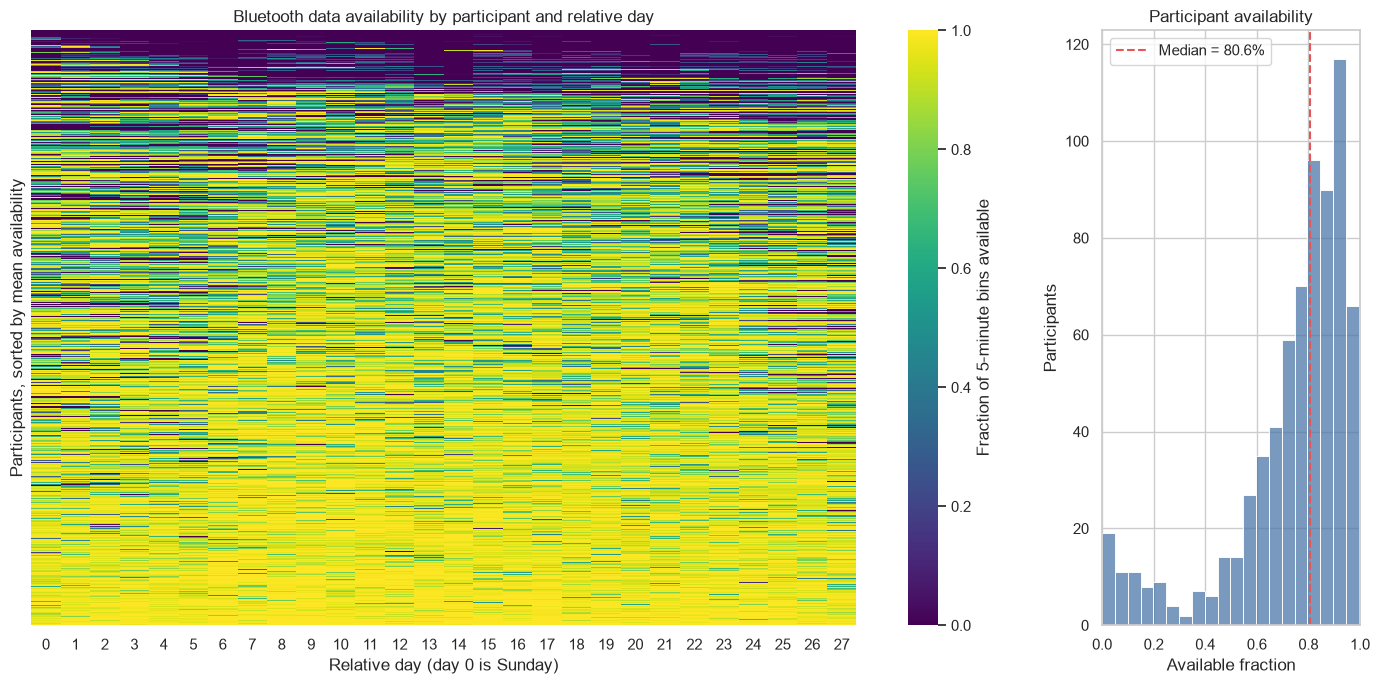

In [ ]:
figure = plot_availability(data)
figure.show()

## 2. Activity by weekday and hour

Compare when proximity, active participants, SMS, and calls occur. Day zero in the data is Sunday.

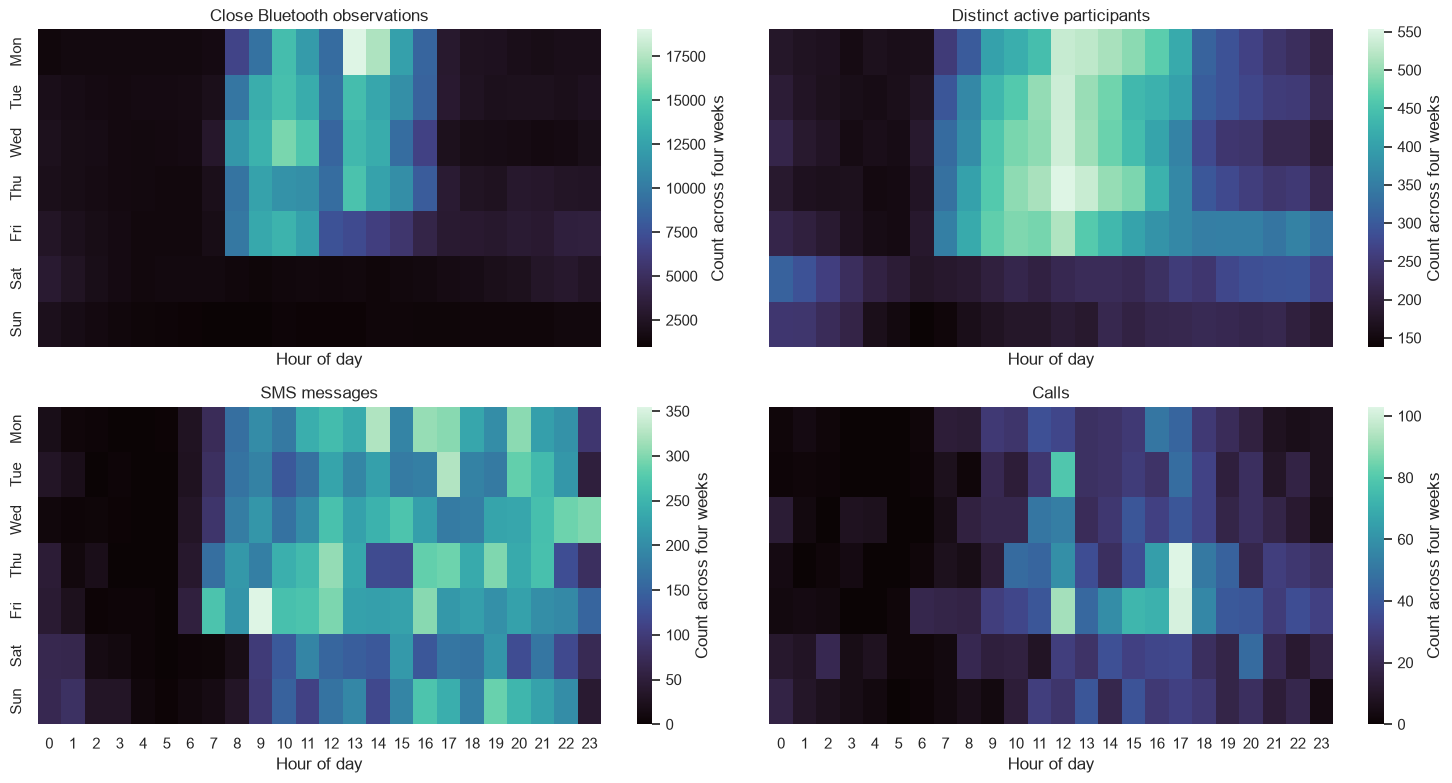

In [ ]:
figure = plot_temporal_activity(data)
figure.show()

## 3. RSSI threshold sensitivity

A stricter threshold produces fewer physical ties but those ties align more strongly with Facebook friendship.

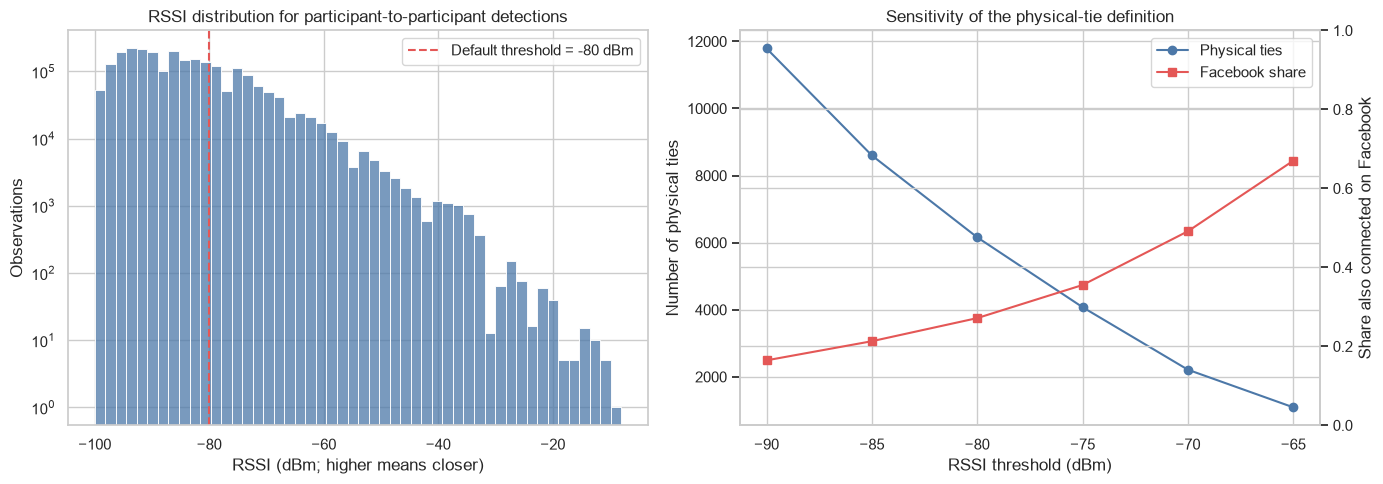

In [5]:
figure = plot_rssi_and_threshold_sensitivity(data)
figure.show()

## 4. Facebook friendship versus proximity

The left panel shows the share of pairs with at least a given amount of close proximity; the right compares the two distributions.

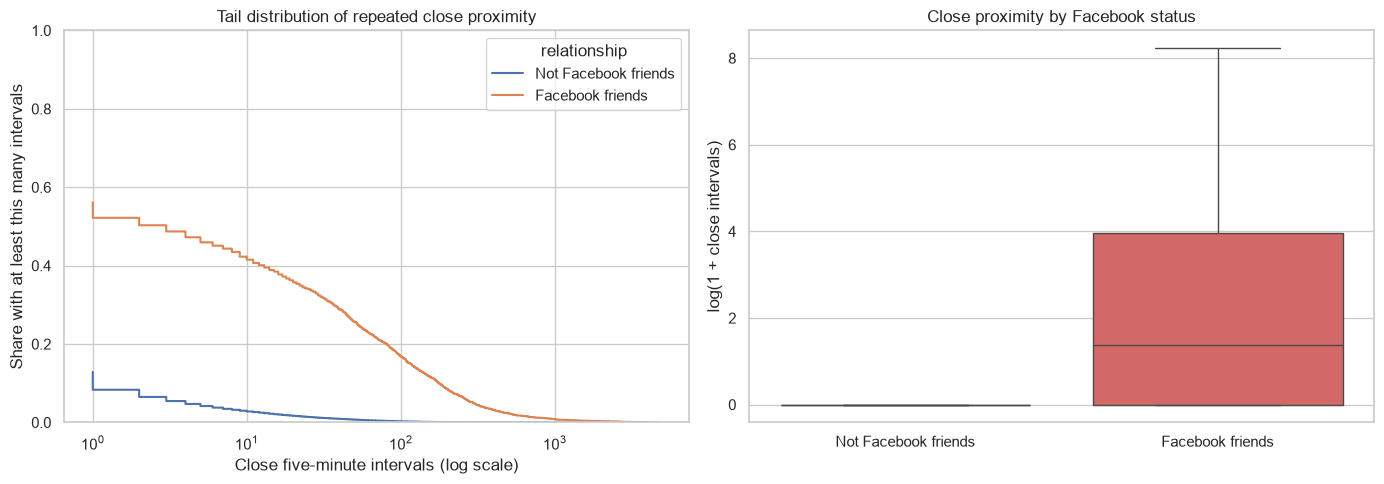

In [6]:
figure = plot_facebook_proximity_distributions(data)
figure.show()

## 5. Exact overlap among network layers

Filled dots identify each exact combination of Facebook, calls, SMS, and repeated proximity.

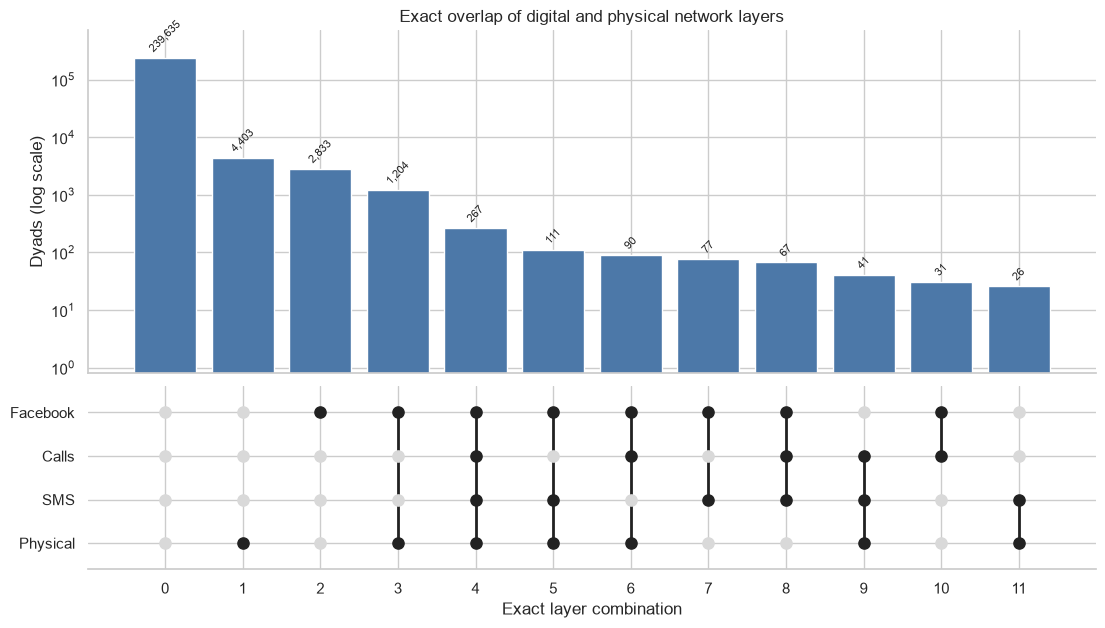

In [7]:
figure = plot_layer_upset(data)
figure.show()

## 6. Direct communication versus proximity

These density plots compare call/SMS volume with close Bluetooth observations, separated by Facebook status.

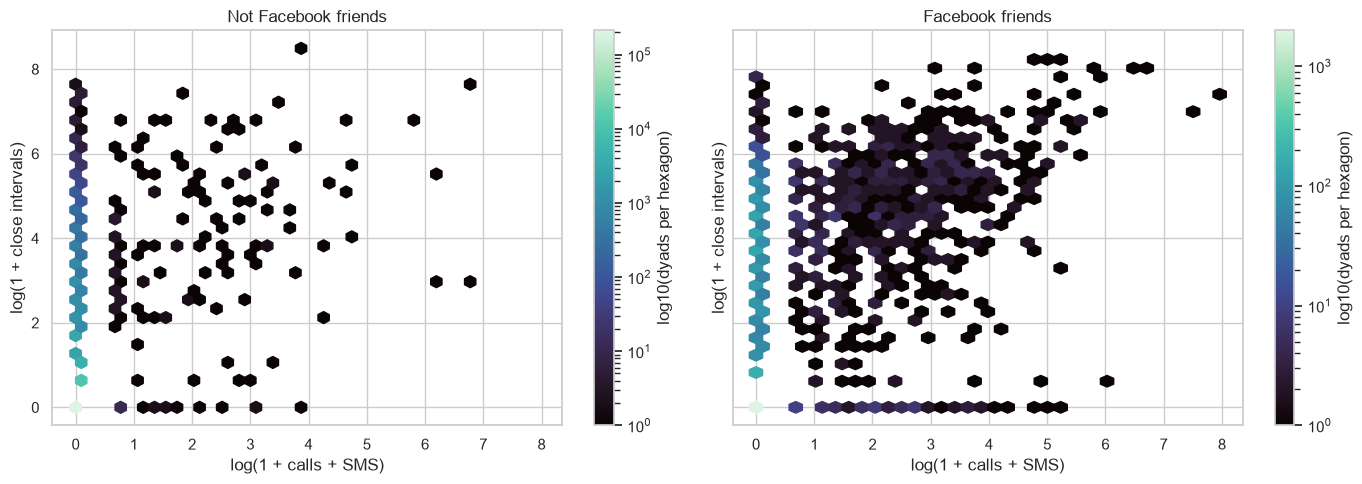

In [8]:
figure = plot_digital_vs_physical(data)
figure.show()

## 7. Cross-layer strength concentration

This measures how much call and SMS activity is captured by the strongest physical dyads.

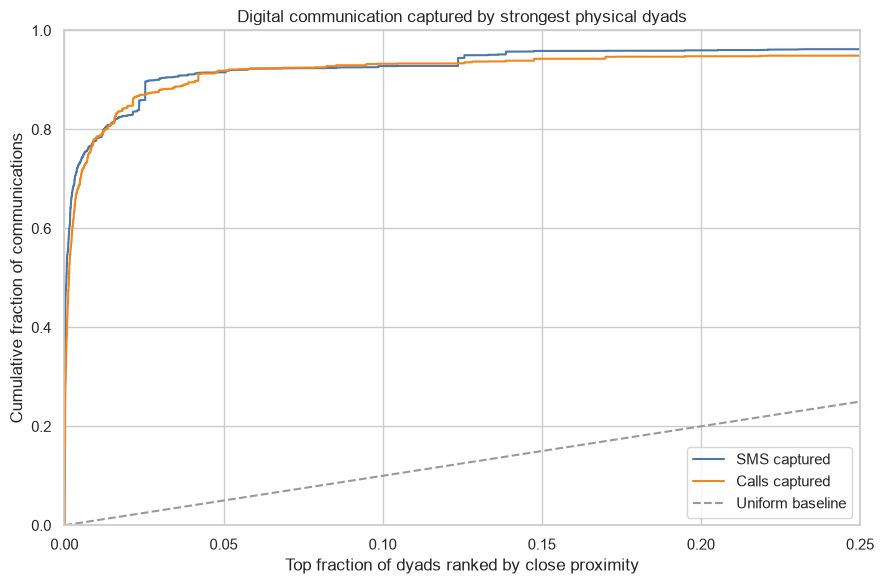

In [9]:
figure = plot_overlap_strength_curve(data)
figure.show()

## 8. Multiplex ego network

A focused ego network is more readable than attempting to draw all 706 participants.

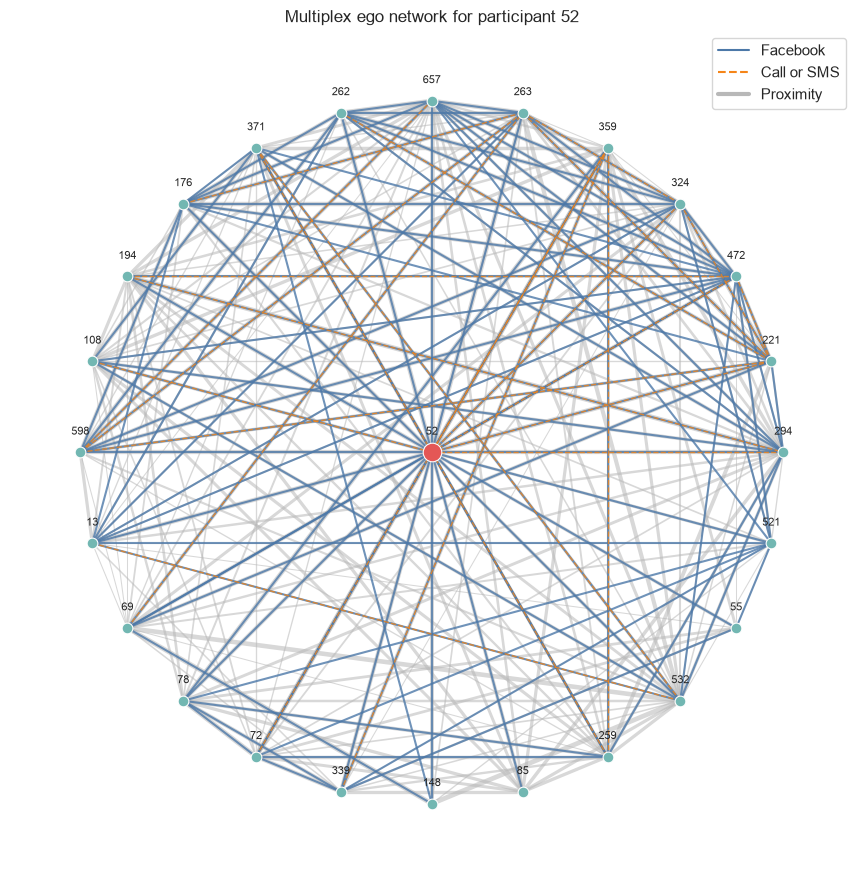

In [10]:
figure = plot_ego_multiplex(data)
figure.show()

## 9. Probability of a repeated physical tie

This is descriptive evidence that digital connections contain predictive signal. It is not yet an out-of-sample model score.

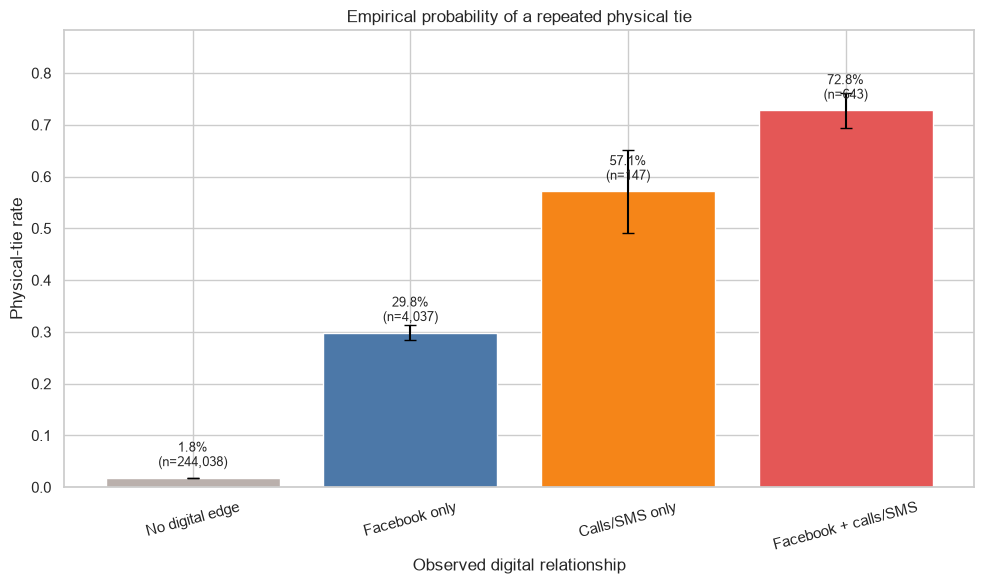

In [11]:
figure = plot_physical_tie_probability(data)
figure.show()

## Modeling cautions

- The prediction unit is a participant pair.
- Prefer precision-recall AUC, calibration, and lift over accuracy because positive ties are rare.
- Use node-aware validation so the same participants do not freely appear in both training and testing.
- Facebook is an end-of-window snapshot; describe same-window results as association, not causation.
- Repeat the model under several physical-tie definitions.